# Results

## Librairies

In [139]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Get results

In [140]:
results_folder = "."
file_name = "results_0_1000_nlp.csv"

In [141]:
results_df = pd.read_csv(file_name, header=None)
results_df.columns = ['error_1', 'error_2', 'error_3', 'error_polytope']

In [142]:
results_df

,error_1,error_2,error_3,error_polytope
0,0.000338,0.000338,0.000338,1.231378
1,0.000008,0.000008,0.000008,0.000008
2,0.000024,0.000024,0.000024,1.248668
3,0.000031,0.000031,0.000031,1.252451
4,0.001954,0.001954,0.001954,1.246753
...,...,...,...,...
995,0.041936,0.041936,0.041936,1.257530
996,0.000014,0.000014,0.000014,1.232788
997,0.000019,0.000019,0.000019,1.226916
998,0.000134,0.000134,0.000134,1.257505


In [143]:
results_df.shape

(1000, 4)

In [144]:
# sanity check
tolerance = 1e-6

mask_1 = ((results_df['error_1'] - results_df['error_2']).abs() < tolerance).all()
mask_2 = ((results_df['error_2'] - results_df['error_3']).abs() < tolerance).all()
mask_3 = ((results_df['error_3'] - results_df['error_1']).abs() < tolerance).all()

mask = (mask_1 and mask_2 and mask_3).item()

mask

True

## Results

In [145]:
errors_samples = results_df['error_1']
errors_polytopes = results_df['error_polytope']

In [146]:
max_samples = np.max(errors_samples)
max_polytopes = np.max(errors_polytopes)

max_samples, max_polytopes

(np.float64(1.03934931), np.float64(1.265612949985812))

#### Problematic samples

In [147]:
mask_pb = errors_samples >= errors_polytopes
indices_pb = mask_pb[mask_pb].index

print(f"There are {len(indices_pb)} problematic samples at indices:")
indices_pb

There are 98 problematic samples at indices:


Index([ 24,  55,  75,  81,  89, 101, 115, 129, 146, 150, 159, 161, 184, 192,
       195, 255, 257, 265, 272, 277, 283, 301, 308, 313, 326, 329, 342, 350,
       354, 365, 374, 389, 395, 398, 400, 417, 423, 430, 435, 450, 452, 460,
       468, 502, 503, 504, 507, 508, 514, 519, 538, 545, 558, 575, 583, 592,
       596, 599, 624, 628, 630, 657, 661, 664, 683, 686, 690, 691, 694, 711,
       716, 728, 729, 740, 754, 756, 760, 777, 779, 786, 790, 794, 798, 804,
       831, 832, 833, 872, 879, 882, 909, 915, 932, 948, 963, 965, 978, 979],
      dtype='int64')

In [148]:
results_pb_df = results_df.loc[indices_pb]
results_pb_df.head()

,error_1,error_2,error_3,error_polytope
24,1.290000e-06,1.290000e-06,1.290000e-06,1.285110e-06
55,6.100000e-07,6.100000e-07,6.100000e-07,6.079106e-07
75,1.000000e-08,1.000000e-08,1.000000e-08,8.572733e-09
81,2.000000e-08,2.000000e-08,2.000000e-08,1.698141e-08
89,1.130000e-06,1.130000e-06,1.130000e-06,1.128830e-06


**Same sample and polytope errors**

- In these cases, the solver fails to converge and keeps the original solution as the optimal one

In [164]:
mask_pb_1

24     True
55     True
75     True
81     True
89     True
       ... 
948    True
963    True
965    True
978    True
979    True
Length: 98, dtype: bool

In [158]:
# sanity check
tol = 1e-6

mask_pb_1 = ((results_pb_df['error_1'] - results_pb_df['error_polytope']).abs() < tol)
indices_pb_1 = mask_pb_1[mask_pb_1].index

print(f"There are {len(indices_pb_1)}/{len(indices_pb)} problematic samples for which the solver failed to converge.")
print(f"In these cases, the sample and polytope errors are the same (up to tolerance {tol}):")

indices_pb_1

There are 98/98 problematic samples for which the solver failed to converge.
In these cases, the sample and polytope errors are the same (up to tolerance 1e-06):


Index([ 24,  55,  75,  81,  89, 101, 115, 129, 146, 150, 159, 161, 184, 192,
       195, 255, 257, 265, 272, 277, 283, 301, 308, 313, 326, 329, 342, 350,
       354, 365, 374, 389, 395, 398, 400, 417, 423, 430, 435, 450, 452, 460,
       468, 502, 503, 504, 507, 508, 514, 519, 538, 545, 558, 575, 583, 592,
       596, 599, 624, 628, 630, 657, 661, 664, 683, 686, 690, 691, 694, 711,
       716, 728, 729, 740, 754, 756, 760, 777, 779, 786, 790, 794, 798, 804,
       831, 832, 833, 872, 879, 882, 909, 915, 932, 948, 963, 965, 978, 979],
      dtype='int64')

In [160]:
results_pb_1_df = results_df.loc[indices_pb_1]
results_pb_1_df.head()

,error_1,error_2,error_3,error_polytope
24,1.290000e-06,1.290000e-06,1.290000e-06,1.285110e-06
55,6.100000e-07,6.100000e-07,6.100000e-07,6.079106e-07
75,1.000000e-08,1.000000e-08,1.000000e-08,8.572733e-09
81,2.000000e-08,2.000000e-08,2.000000e-08,1.698141e-08
89,1.130000e-06,1.130000e-06,1.130000e-06,1.128830e-06


**Small polytopes errors**

In [170]:
# sanity check

mask_pb_2 = ~mask_pb_1
indices_pb_2 = mask_pb_2[mask_pb_2].index

print(f"There are {len(indices_pb_2)}/{len(indices_pb)} problematic samples with inconsistent polytope error.")
print(f"In these cases, the sample errors are much larger than the polytope errors (impossible):")

indices_pb_2

There are 0/98 problematic samples with inconsistent polytope error.
In these cases, the sample errors are much larger than the polytope errors (impossible):


Index([], dtype='int64')

In [171]:
results_pb_2_df = results_df.loc[indices_pb_2]
results_pb_2_df

,error_1,error_2,error_3,error_polytope


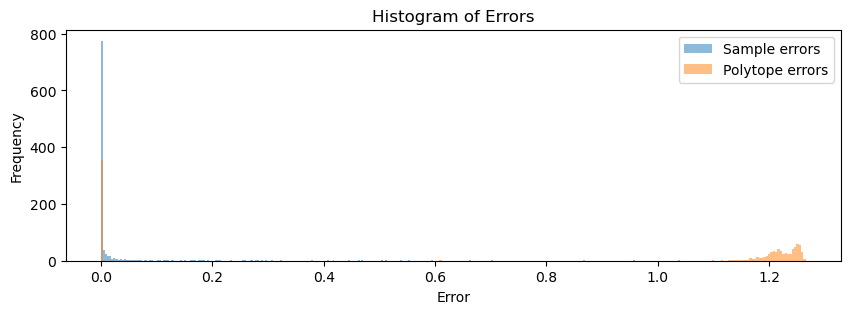

In [156]:
plt.figure(figsize=(10,3))
plt.hist(results_df['error_1'], bins=300, alpha=0.5, label='Sample errors')
plt.hist(results_df['error_polytope'], bins=300, alpha=0.5, label='Polytope errors')

plt.xlabel('Error')
plt.ylabel('Frequency')
plt.title('Histogram of Errors')
plt.legend()
# plt.grid(True)
plt.show()
